# 데이터구조 02강 실습 및 과제
## 알고리즘 복잡도와 Big-O

**과목**: 데이터구조 | **담당교수**: 임화정 | **차시**: 02. 알고리즘 복잡도와 Big-O

본 노트북은 강의에서 다룬 시간 복잡도(O(1), O(n), O(n²))와 탐색 알고리즘(선형 탐색, 이분 탐색)을
직접 코드로 확인하고, 실습 및 과제를 수행하기 위한 템플릿입니다.

---
## 0. 실습 목표

- 입력 크기 n에 따른 알고리즘 실행 시간 변화를 코드로 직접 확인한다.
- O(1), O(n), O(n²) 복잡도의 차이를 실제 실행 시간으로 체감한다.
- 선형 탐색과 이분 탐색을 구현하고, 두 알고리즘의 성능 차이를 비교한다.
- Big-O 이론값과 실제 측정값을 비교 분석하는 과제를 수행한다.

---
## 1. O(1) : 상수 시간 예제

데이터 양과 무관하게 항상 일정한 연산 횟수를 가지는 예시입니다. 배열의 첫 번째 원소에 접근하는 연산은
데이터 크기가 10개든 100만 개든 단 1번의 연산으로 끝납니다.

In [1]:
def get_first_item(data):
    """O(1) - 상수 시간: 데이터 크기와 무관하게 항상 1번의 연산"""
    return data[0]

import time  #time.perf_counter() 시간 측정을 위한 고성능 카운터

small_data = list(range(10))
large_data = list(range(1_000_000))

start = time.perf_counter()
result_small = get_first_item(small_data)
end = time.perf_counter()
print(f"작은 데이터(n=10) 결과: {result_small}, 소요 시간: {end - start:.10f}s")

start = time.perf_counter()
result_large = get_first_item(large_data)
end = time.perf_counter()
print(f"큰 데이터(n=1,000,000) 결과: {result_large}, 소요 시간: {end - start:.10f}s")

print("\n결론: 데이터 크기가 커져도 실행 시간은 거의 동일함을 확인할 수 있습니다.")

작은 데이터(n=10) 결과: 0, 소요 시간: 0.0000013330s
큰 데이터(n=1,000,000) 결과: 0, 소요 시간: 0.0000006660s

결론: 데이터 크기가 커져도 실행 시간은 거의 동일함을 확인할 수 있습니다.


---
## 2. O(n) : 선형 시간 예제

데이터 크기 n에 정비례하여 연산 횟수가 증가하는 예시입니다. 모든 원소를 한 번씩 순회하는
반복문이 대표적인 O(n) 구조입니다.

In [2]:
def print_all_items(data):
    """O(n) - 선형 시간: 데이터 크기에 정비례하여 연산 횟수 증가"""
    count = 0
    for item in data:
        count += 1
    return count

import time

for n in [1_000, 10_000, 100_000, 1_000_000]:
    data = list(range(n))
    start = time.perf_counter()
    print_all_items(data)
    end = time.perf_counter()
    print(f"n = {n:>10,}  ->  소요 시간: {end - start:.6f}s")

n =      1,000  ->  소요 시간: 0.000017s
n =     10,000  ->  소요 시간: 0.000158s
n =    100,000  ->  소요 시간: 0.001666s
n =  1,000,000  ->  소요 시간: 0.021253s


---
## 3. O(n²) : 제곱 시간 예제

중첩 반복문으로 인해 n의 제곱에 비례하여 연산 횟수가 폭증하는 예시입니다.
n이 커질수록 실행 시간이 매우 빠르게 증가하므로 테스트 범위를 작게 설정했습니다.

In [3]:
def count_all_pairs(data):
    """O(n^2) - 제곱 시간: 중첩 루프로 인해 n의 제곱에 비례하여 연산 횟수 증가"""
    count = 0
    for i in data:
        for j in data:
            count += 1
    return count

import time

for n in [100, 500, 1_000, 2_000]:
    data = list(range(n))
    start = time.perf_counter()
    count_all_pairs(data)
    end = time.perf_counter()
    print(f"n = {n:>6,}  ->  연산 횟수: {n*n:>12,}  소요 시간: {end - start:.6f}s")

print("\n주목: n이 2배가 되면(1,000 -> 2,000) 실행 시간은 약 4배로 증가합니다 (n^2 특성).")

n =    100  ->  연산 횟수:       10,000  소요 시간: 0.000168s
n =    500  ->  연산 횟수:      250,000  소요 시간: 0.004099s
n =  1,000  ->  연산 횟수:    1,000,000  소요 시간: 0.015645s
n =  2,000  ->  연산 횟수:    4,000,000  소요 시간: 0.063468s

주목: n이 2배가 되면(1,000 -> 2,000) 실행 시간은 약 4배로 증가합니다 (n^2 특성).


---
## 4. 선형 탐색 (Linear Search) 구현

데이터의 처음부터 끝까지 순차적으로 값을 비교하는 탐색 방식입니다.
- Best Case: O(1) - 첫 번째 원소가 target인 경우
- Worst Case: O(n) - target이 마지막에 있거나 존재하지 않는 경우

In [4]:
def linear_search(data, target):
    """
    선형 탐색: 데이터를 처음부터 끝까지 순차적으로 확인
    반환값: target의 인덱스, 없으면 -1
    """
    for i in range(len(data)):
        if data[i] == target:
            return i
    return -1

test_data = [4, 2, 9, 7, 1, 5, 8, 3, 6, 0]
print("선형 탐색 결과 (target=7):", linear_search(test_data, 7))
print("선형 탐색 결과 (target=100):", linear_search(test_data, 100))

선형 탐색 결과 (target=7): 3
선형 탐색 결과 (target=100): -1


---
## 5. 이분 탐색 (Binary Search) 구현

정렬된 데이터에서 탐색 범위를 절반씩 좁혀가며 값을 찾는 방식입니다.
- 전제 조건: 데이터가 반드시 정렬되어 있어야 함
- Worst Case: O(log n)

In [5]:
def binary_search(data, target):
    """
    이분 탐색: 정렬된 데이터에서 탐색 범위를 절반씩 줄여가며 탐색
    반환값: target의 인덱스, 없으면 -1
    """
    left, right = 0, len(data) - 1
    while left <= right:
        mid = (left + right) // 2
        if data[mid] == target:
            return mid
        elif data[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return -1

sorted_data = sorted(test_data)
print("정렬된 데이터:", sorted_data)
print("이분 탐색 결과 (target=7):", binary_search(sorted_data, 7))
print("이분 탐색 결과 (target=100):", binary_search(sorted_data, 100))

정렬된 데이터: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
이분 탐색 결과 (target=7): 7
이분 탐색 결과 (target=100): -1


---
## 6. 성능 측정 실습 - 데이터 크기별 실행 시간 비교

n을 10부터 1,000,000까지 변화시키며 선형 탐색과 이분 탐색의 실행 시간을 측정합니다.
각 경우 최악의 경우(마지막 원소를 찾는 경우)를 기준으로 측정합니다.

In [6]:
import time

sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
linear_times = []
binary_times = []

for n in sizes:
    data = list(range(n))   # 이미 정렬된 상태
    target = n - 1           # 최악의 경우: 마지막 원소 탐색

    start = time.perf_counter()
    linear_search(data, target)
    end = time.perf_counter()
    linear_times.append(end - start)

    start = time.perf_counter()
    binary_search(data, target)
    end = time.perf_counter()
    binary_times.append(end - start)

print(f"{'n':>12} | {'선형 탐색(s)':>15} | {'이분 탐색(s)':>15}")
print("-" * 50)
for n, lt, bt in zip(sizes, linear_times, binary_times):
    print(f"{n:>12,} | {lt:>15.8f} | {bt:>15.8f}")

           n |        선형 탐색(s) |        이분 탐색(s)
--------------------------------------------------
          10 |      0.00000138 |      0.00000100
         100 |      0.00000317 |      0.00000104
       1,000 |      0.00002425 |      0.00000233
      10,000 |      0.00021383 |      0.00000204
     100,000 |      0.00204433 |      0.00000262
   1,000,000 |      0.02332896 |      0.00000650


In [ ]:
# macOS 한글 폰트 준비
from pathlib import Path
import matplotlib.font_manager as fm

font_path = Path('/System/Library/Fonts/Supplemental/AppleGothic.ttf')
if not font_path.is_file():
    raise FileNotFoundError(f'macOS 한글 폰트 파일을 찾을 수 없습니다: {font_path}')

fm.fontManager.addfont(str(font_path))

In [ ]:
# matplotlib에 macOS 한글 폰트 적용
import matplotlib.pyplot as plt

font_name = fm.FontProperties(fname=str(font_path)).get_name()
plt.rcParams['font.family'] = font_name
# 음수 눈금은 유니코드 마이너스(−) 대신 일반 하이픈(-)으로 표시

plt.rcParams['axes.unicode_minus'] = False
print(f'적용된 한글 폰트: {font_name}')

적용된 한글 폰트: AppleGothic


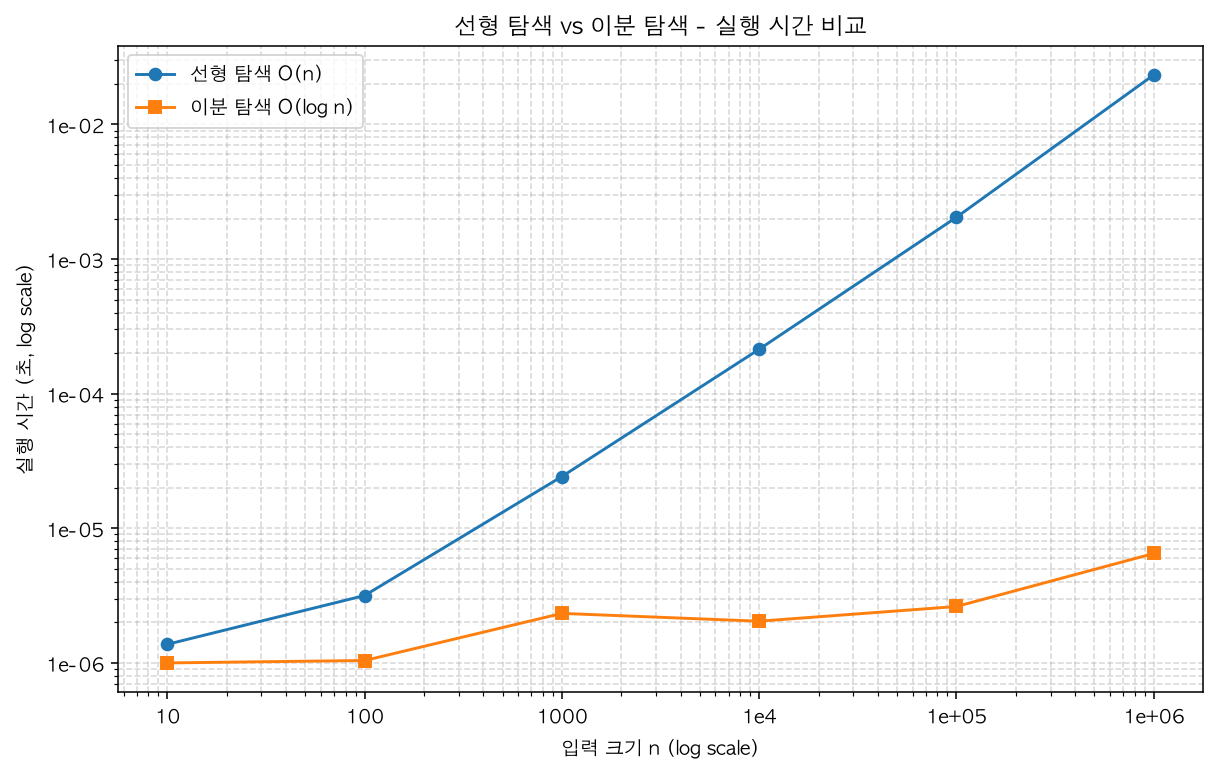

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker #10^{-3} 같은 mathtext를 쓰면 한글 유니코드 − 문자(U+2212) 에러

plt.figure(figsize=(10, 6))
plt.plot(sizes, linear_times, marker='o', label='선형 탐색 O(n)')
plt.plot(sizes, binary_times, marker='s', label='이분 탐색 O(log n)')
plt.xscale('log')
plt.yscale('log')

# 핵심: log scale 기본 mathtext formatter 대신 일반 formatter 사용
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.LogFormatter(base=10))
ax.yaxis.set_major_formatter(mticker.LogFormatter(base=10))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

plt.xlabel('입력 크기 n (log scale)')
plt.ylabel('실행 시간 (초, log scale)')
plt.title('선형 탐색 vs 이분 탐색 - 실행 시간 비교')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

---
## 7. Big-O 이론값과 실제 측정값 비교 분석

이론적인 연산 횟수(선형 탐색은 n, 이분 탐색은 log2 n)와 실제 측정된 실행 시간을 나란히 비교합니다.

In [10]:
import math

print(f"{'n':>12} | {'이론 O(n)':>13} | {'이론 O(log n)':>13} | {'실제 선형(s)':>10} | {'실제 이분(s)':>10}")
print("-" * 85)
for n, lt, bt in zip(sizes, linear_times, binary_times):
    theoretical_linear = n
    theoretical_binary = math.log2(n) if n > 0 else 0
    print(f"{n:>12,} | {theoretical_linear:>15,} | {theoretical_binary:>15.2f} | {lt:>14.8f} | {bt:>14.8f}")

print("\n분석: 이론적 연산 횟수(O(n), O(log n))의 증가 추세와 실제 측정된 실행 시간의 증가 추세가")
print("유사한 패턴을 보이는지 비교해보세요. (실제 시간은 시스템 환경, 캐시, 오버헤드 등의 영향을 받습니다)")

           n |       이론 O(n) |   이론 O(log n) |   실제 선형(s) |   실제 이분(s)
-------------------------------------------------------------------------------------
          10 |              10 |            3.32 |     0.00000138 |     0.00000100
         100 |             100 |            6.64 |     0.00000317 |     0.00000104
       1,000 |           1,000 |            9.97 |     0.00002425 |     0.00000233
      10,000 |          10,000 |           13.29 |     0.00021383 |     0.00000204
     100,000 |         100,000 |           16.61 |     0.00204433 |     0.00000262
   1,000,000 |       1,000,000 |           19.93 |     0.02332896 |     0.00000650

분석: 이론적 연산 횟수(O(n), O(log n))의 증가 추세와 실제 측정된 실행 시간의 증가 추세가
유사한 패턴을 보이는지 비교해보세요. (실제 시간은 시스템 환경, 캐시, 오버헤드 등의 영향을 받습니다)


---
# 8. 과제 (Assignment)

**과제 가이드라인** (강의자료 16페이지 기준)

- 선형 탐색과 이분 탐색의 실행 시간을 데이터 크기 n의 변화에 따라 측정합니다.
- n = 10 ~ 1,000,000(100만) 범위에서 측정하고, 결과를 표와 그래프로 포함합니다.
- Big-O 이론값과 실제 측정값을 비교 분석합니다.
- 제출 형식: PDF 파일, 제출처: e-Campus, 제출 기한: 다음 주 수업 시작 전까지

실행 시간: 탐색 1회당 시간 (5회 배치 측정의 중앙값)
         n |         선형(s) |         이분(s) |    O(n): n |   log2(n) |      선형/이분
-------------------------------------------------------------------------------------
        10 |   0.000000345 |   0.000000391 |         10 |      3.32 |      0.88배
       100 |   0.000001741 |   0.000000630 |        100 |      6.64 |      2.76배
     1,000 |   0.000020252 |   0.000000878 |      1,000 |      9.97 |     23.06배
    10,000 |   0.000211604 |   0.000001277 |     10,000 |     13.29 |    165.74배
   100,000 |   0.002058708 |   0.000001456 |    100,000 |     16.61 |   1413.46배
 1,000,000 |   0.020681750 |   0.000001754 |  1,000,000 |     19.93 |  11792.20배


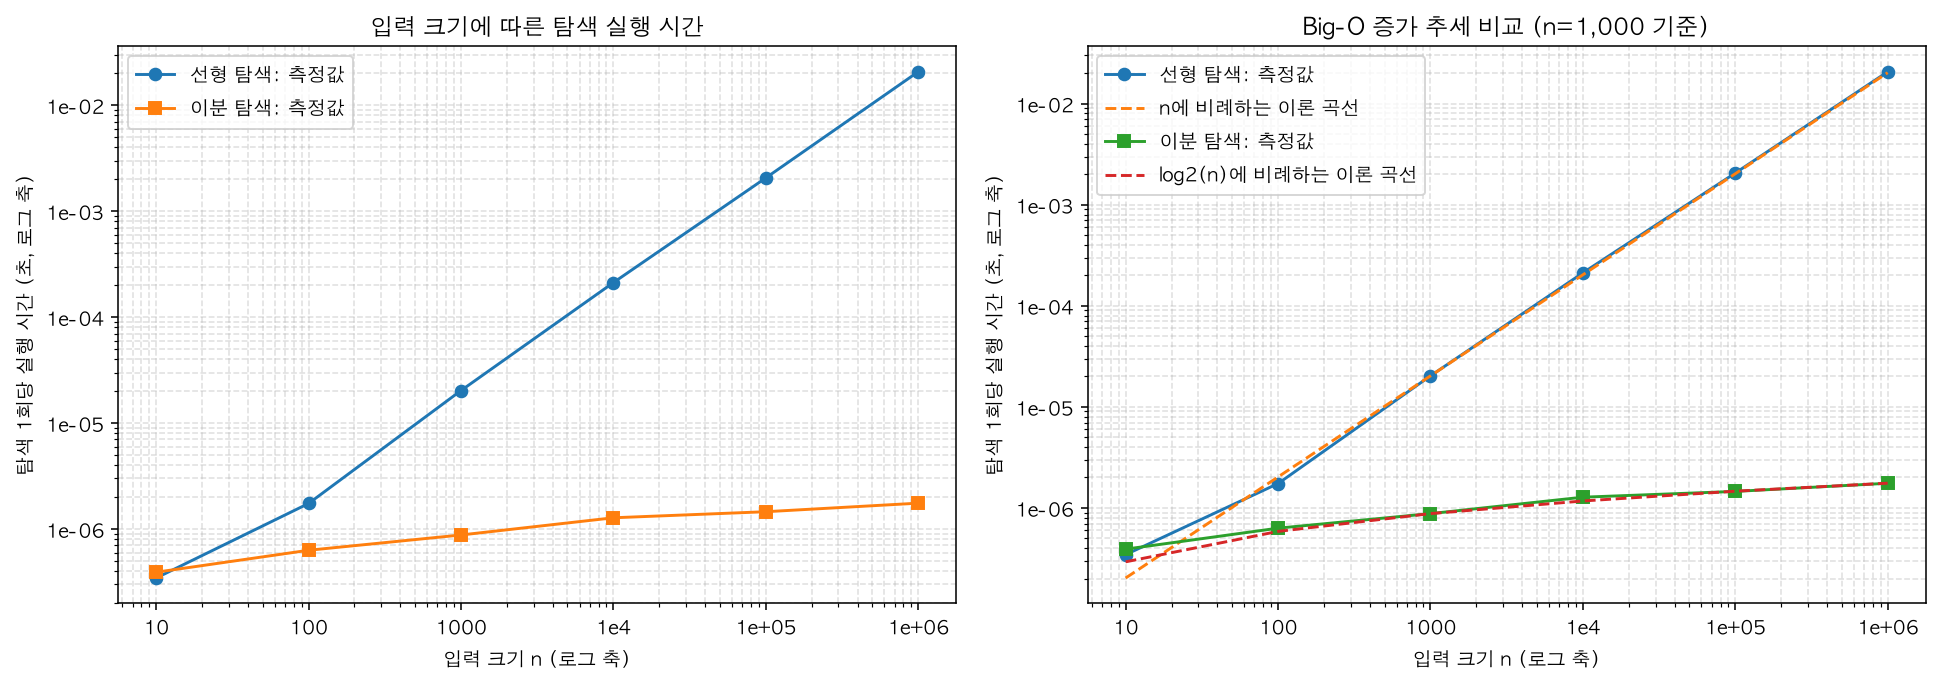


이론적 증가량으로 나눈 실행 시간
         n |          선형 시간/n (s) |         이분 시간/log2(n) (s)
-----------------------------------------------------------------
        10 |            3.449e-08 |                 1.177e-07
       100 |            1.741e-08 |                 9.488e-08
     1,000 |            2.025e-08 |                 8.814e-08
    10,000 |            2.116e-08 |                 9.608e-08
   100,000 |            2.059e-08 |                 8.769e-08
 1,000,000 |            2.068e-08 |                 8.799e-08

n=10 → 1,000,000: 입력 크기 100,000배
선형 탐색 시간 증가: 59,971.00배
이분 탐색 시간 증가: 4.49배
이론적 증가: n은 100,000배, log2(n)은 6.00배


In [ ]:
# ===== 과제 템플릿 =====
# 아래 TODO 부분을 채워서 과제를 완성하세요.

import math
import statistics
import timeit
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# TODO 1: n = 10 ~ 1,000,000 범위에서 다양한 n 값을 리스트로 정의하세요.
#          (예: 등비수열로 10, 100, 1000, ... 또는 원하는 간격으로 지정)
assignment_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]

# TODO 2: 각 n에 대해 선형 탐색과 이분 탐색의 실행 시간을 측정하여
#          아래 리스트에 저장하세요. (최악의 경우를 기준으로 측정 권장)
assignment_linear_times = []
assignment_binary_times = []

def measure_search(search_function, data, target, number):
    """5회 배치 측정 후, 탐색 1회당 평균 시간들의 중앙값을 반환"""
    # 짧은 탐색은 여러 번 실행하여 타이머 해상도와 순간적인 잡음의 영향 최소화
    # 데이터 생성과 정렬은 타이머 미포함
    search_function(data, target)  # 최초 호출의 영향을 줄이기 위한 예열
    elapsed_times = timeit.repeat(
        lambda: search_function(data, target), repeat=5, number=number
    )
    return statistics.median(elapsed_times) / number

for n in assignment_sizes:
    data = list(range(n))  # 이분 탐색의 전제 조건을 만족하는 오름차순 데이터
    target = n - 1  # 선형 탐색은 n개 확인, 이분 탐색도 최대 반복 횟수에 도달

    # 작은 n에서는 반복 수를 늘리고, 큰 n에서는 전체 실험 시간을 제한
    linear_number = max(1, 100_000 // n)
    assignment_linear_times.append(
        measure_search(linear_search, data, target, linear_number)
    )
    assignment_binary_times.append(
        measure_search(binary_search, data, target, number=5_000)
    )

# TODO 3: 측정 결과를 표 형태로 출력하세요.
# 측정 결과와 이론적인 증가량을 같은 표에서 비교
# 현재 이분 탐색에서 마지막 원소를 찾을 때 반복 횟수는 floor(log2(n)) + 1
print('실행 시간: 탐색 1회당 시간 (5회 배치 측정의 중앙값)')
print(f"{'n':>10} | {'선형(s)':>13} | {'이분(s)':>13} | {'O(n): n':>10} | {'log2(n)':>9} | {'선형/이분':>10}")
print('-' * 85)
for n, lt, bt in zip(assignment_sizes, assignment_linear_times, assignment_binary_times):
    print(f'{n:>10,} | {lt:>13.9f} | {bt:>13.9f} | {n:>10,} | {math.log2(n):>9.2f} | {lt / bt:>9.2f}배')

# TODO 4: 측정 결과를 그래프로 시각화하세요. (matplotlib 사용, x축/y축 log scale 권장)
reference_index = assignment_sizes.index(1_000)
reference_n = assignment_sizes[reference_index]
linear_theory = [
    assignment_linear_times[reference_index] * n / reference_n
    for n in assignment_sizes
]
binary_theory = [
    assignment_binary_times[reference_index] * math.log2(n) / math.log2(reference_n)
    for n in assignment_sizes
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(assignment_sizes, assignment_linear_times, 'o-', label='선형 탐색: 측정값')
axes[0].plot(assignment_sizes, assignment_binary_times, 's-', label='이분 탐색: 측정값')
axes[0].set_title('입력 크기에 따른 탐색 실행 시간')

axes[1].plot(assignment_sizes, assignment_linear_times, 'o-', label='선형 탐색: 측정값')
axes[1].plot(assignment_sizes, linear_theory, '--', label='n에 비례하는 이론 곡선')
axes[1].plot(assignment_sizes, assignment_binary_times, 's-', label='이분 탐색: 측정값')
axes[1].plot(assignment_sizes, binary_theory, '--', label='log2(n)에 비례하는 이론 곡선')
axes[1].set_title('Big-O 증가 추세 비교 (n=1,000 기준)')

for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('입력 크기 n (로그 축)')
    ax.set_ylabel('탐색 1회당 실행 시간 (초, 로그 축)')
    # 한글 폰트와 함께 사용할 수 있도록 일반 로그 눈금 표기를 사용
    ax.xaxis.set_major_formatter(mticker.LogFormatter(base=10))
    ax.yaxis.set_major_formatter(mticker.LogFormatter(base=10))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# TODO 5: Big-O 이론값(O(n), O(log n))과 실제 측정값을 비교하는 코드를 작성하세요.
print('\n이론적 증가량으로 나눈 실행 시간')
print(f"{'n':>10} | {'선형 시간/n (s)':>20} | {'이분 시간/log2(n) (s)':>25}")
print('-' * 65)
for n, lt, bt in zip(assignment_sizes, assignment_linear_times, assignment_binary_times):
    print(f'{n:>10,} | {lt / n:>20.3e} | {bt / math.log2(n):>25.3e}')

print(f'\nn=10 → 1,000,000: 입력 크기 {assignment_sizes[-1] / assignment_sizes[0]:,.0f}배')
print(f'선형 탐색 시간 증가: {assignment_linear_times[-1] / assignment_linear_times[0]:,.2f}배')
print(f'이분 탐색 시간 증가: {assignment_binary_times[-1] / assignment_binary_times[0]:,.2f}배')
print(f'이론적 증가: n은 100,000배, log2(n)은 {math.log2(assignment_sizes[-1]) / math.log2(assignment_sizes[0]):.2f}배')

---
## 9. 과제 결과 분석 (서술형 답안)

아래 질문에 대한 답을 직접 작성해 보세요. 이 마크다운 셀을 더블클릭하여 수정할 수 있습니다.

**1. 선형 탐색과 이분 탐색의 실행 시간은 n이 증가함에 따라 어떻게 변화했습니까?**

최악의 경우를 가정하였을때 선형 탐색의 실행 시간은 입력 크기 n이 커질수록 대체로 n에 비례하여 증가하였습니다. n=1,000에서 약 0.00002025초, n=10,000에서 약 0.00021160초, n=100,000에서 약 0.00205871초, n=1,000,000에서 약 0.02068175초가 걸렸습니다. 이 구간에서는 n이 10배가 될 때 실행 시간도 약 10배가 되었습니다. 마지막 원소를 찾기 위해 배열의 모든 원소를 순서대로 확인하기 때문입니다.

이분 탐색은 n=10에서 약 0.000000391초, n=1,000,000에서 약 0.000001754초가 걸렸습니다. 입력 크기가 100,000배 증가하는 동안 실행 시간은 약 4.49배만 증가하였습니다. 탐색 범위를 매번 절반으로 줄이므로 큰 배열에서도 필요한 반복 횟수가 적기 때문입니다. n=1,000,000에서 이분 탐색은 선형 탐색보다 약 11,792배 빨랐습니다. 다만 n=10에서는 선형 탐색이 조금 더 빨랐으므로, 데이터가 매우 작을 때도 이분 탐색이 항상 빠른 것은 아닙니다.

**2. 이론적인 Big-O 복잡도와 실제 측정된 실행 시간의 증가 추세가 일치했습니까? 차이가 있다면 그 이유는 무엇일까요?**

전체적인 증가 추세는 선형 탐색의 O(n), 이분 탐색의 O(log n)과 대체로 일치하였습니다. 특히 n=1,000 이상에서 선형 탐색의 시간/n은 약 2.0~2.1 × 10⁻⁸초로 비교적 일정했고, 이분 탐색의 시간/log2(n)도 약 8.8~9.6 × 10⁻⁸초로 비슷한 수준을 유지하였습니다. 그래프에서도 측정값은 n=1,000을 기준으로 높이를 맞춘 이론 곡선과 유사한 추세를 보였습니다.

그러나 n=10에서 n=1,000,000으로 증가할 때 선형 탐색 시간은 약 59,971배, 이분 탐색 시간은 약 4.49배 증가하여, 이론적 증가량인 100,000배와 6배에 정확히 일치하지는 않았습니다. Big-O는 상수 계수와 낮은 차수의 항을 생략한 점근적인 증가율이므로 정확한 실행 시간이나 배율을 보장하지 않습니다. 실제 측정에는 함수 호출과 반복문 실행 비용, Python 인터프리터의 처리 비용, CPU 캐시, 운영체제의 스케줄링과 다른 작업의 영향, 타이머 해상도 등이 포함됩니다. 특히 작은 n에서는 고정적인 호출 비용의 비중이 큽니다. 반복 측정과 중앙값 사용은 잡음을 줄이지만 완전히 제거하지는 못했습니다.

**3. 실무에서 반복 탐색이 필요한 경우, 정렬 비용을 고려했을 때 어떤 탐색 방법을 선택해야 할까요?**

데이터가 이미 정렬되어 있고 같은 데이터에서 탐색을 반복한다면 이분 탐색을 선택하는 것이 유리합니다. 탐색 횟수를 m이라고 할 때, 선형 탐색의 최악의 경우 총비용은 O(mn)이고 이분 탐색은 O(m log n)이기 때문입니다.

데이터가 정렬되어 있지 않다면 일반적인 비교 정렬의 O(n log n) 비용을 함께 고려해야 합니다. 한 번 정렬한 뒤 m회 이분 탐색하는 총비용은 O(n log n + m log n)입니다. 데이터가 거의 바뀌지 않고 탐색 횟수가 충분히 많다면 초기 정렬 비용을 여러 탐색에 걸쳐 회수할 수 있으므로 정렬 후 이분 탐색이 유리합니다. 실제로 어느 탐색 횟수부터 유리해지는지는 데이터 크기와 구현의 상수 비용에 따라 달라집니다.

반대로 정렬되지 않은 데이터에서 탐색을 한두 번만 수행하거나 데이터가 매우 작다면, 정렬 없이 바로 수행하는 선형 탐색이 더 적합할 수 있습니다. 데이터의 삽입·삭제가 잦다면 정렬 상태를 유지하는 비용도 고려해야 합니다. 따라서 정렬 여부, 탐색 횟수, 데이터 변경 빈도를 함께 보고 선택해야 합니다.


---
## 제출 안내

- 보고서 형식: .ipynb
- 제출처: e-Campus
- 제출 기한: 9/20 18시